## Assessing the baseline of the System Transformation Education Programme (STEP) 

## Import Libraries

In [169]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import logging
from scipy.stats import pearsonr
from IPython.display import display
from IPython.display import Markdown, display

### Load the Raw dataset from an excel file

In [170]:
# Define file path
file_path = r"C:\Users\admin\Downloads\ethiopia_education_synthetic_dataset_5000.xlsx"

# Load Excel File
excel_file = pd.ExcelFile(file_path)

# Print all sheet names in the workbook
print("Sheets available:", excel_file.sheet_names)

# Read the primary dataset
df = pd.read_excel(excel_file, sheet_name='Survey Data (N=5000)')

# Read the codebook / data dictionary (if available)
if 'Codebook' in excel_file.sheet_names:
    codebook = pd.read_excel(excel_file, sheet_name='Codebook')
    print("\nCodebook Loaded Successfully.")

# Display basic structure
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Sheets available: ['Survey Data (N=5000)', 'Codebook & Data Dictionary']

Dataset Shape: 5000 rows, 47 columns



,Student_ID,Region,Location_Type,School_ID,Q1_Distance,Q2_Companion,Q3_Science_Reason,Q4_Teacher_Gift,Q5_Antonym_Older,Literacy_Score_Max5,...,WASH_01_Girls_Stalls,WASH_01_Functional,WASH_02_Handwashing,WASH_03_MHM_Space,WASH_04_Lockable,WASH_04_Privacy,WASH_04_Distance20m,MAT_01_Textbook_Ratio,MAT_02_Gender_Club,MAT_03_Safeguarding_Policy
0,ETH_2026_00001,Oromia,Rural,SCH_031,B,A,D,D,B,1,...,3,1,1,2,1,0,1,2,1,1
1,ETH_2026_00190,Oromia,Rural,SCH_031,B,C,B,A,C,5,...,3,1,1,2,1,0,1,2,1,1
2,ETH_2026_00266,SNNPR,Rural,SCH_031,B,A,B,A,C,4,...,3,1,1,2,1,0,1,2,1,1
3,ETH_2026_00477,Addis Ababa,Urban,SCH_031,B,C,B,A,C,5,...,3,1,1,2,1,0,1,2,1,1
4,ETH_2026_00593,Oromia,Urban,SCH_031,B,C,B,A,C,5,...,3,1,1,2,1,0,1,2,1,1


## Phase 1: Sample Verification & Balance Testing

Verify that the randomization or Propensity Score Matching (PSM) created equivalent Treatment and Control groups before program rollout.

* ***Sample Auditing:*** Confirm sample sizes ($N=5,000$), cluster distributions ($N=150$ schools), and missing data patterns across regions.

* ***Orthogonality / Balance Checks:*** Conduct independent two-sample $t$-tests for continuous metrics (EGRA/EGMA $Z$-scores) and Chi-Square ($\chi^2$) tests for categorical metrics (gender, caregiver education) across groups.
  
* ***Normalized Differences:*** Calculate standardized mean differences (SMD) to confirm all baseline covariates fall within the acceptable balance threshold ($\text{SMD} < 0.10$).

### A. Sample Auditing

In [179]:
# 1. LOAD PREPARED BASELINE DATASET
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 2. SAMPLE AUDITING
print("="*65)
print("PHASE 1: SAMPLE AUDIT SUMMARY")
print("="*65)
print(f"Total Sample Size (N): {len(df)}")
print(f"Total School Clusters (N_clusters): {df['School_ID'].nunique()}")

# Audit missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("Missing Data Audit: Complete dataset (0 missing values).")
else:
    print("Missing Data Audit:\n", missing)

# Recalculate regional summary ensuring unique cluster counts
regional_audit = (
    df.groupby("Region")
    .agg(
        Total_Students=("STEP_Treatment_Group", "count"),
        STEP_Treatment=("STEP_Treatment_Group", lambda x: (x == 1).sum()),
        Control=("STEP_Treatment_Group", lambda x: (x == 0).sum()),
        School_Clusters=(
            "School_ID",
            "nunique",
        ),  # Fixed: Use 'nunique' instead of 'count' or 'sum'
    )
    .reset_index()
)

# Append total row
total_row = pd.DataFrame(
    {
        "Region": ["Total / Global"],
        "Total_Students": [regional_audit["Total_Students"].sum()],
        "STEP_Treatment": [regional_audit["STEP_Treatment"].sum()],
        "Control": [regional_audit["Control"].sum()],
        "School_Clusters": [df["School_ID"].nunique()],
    }
)

audit_table_clean = pd.concat([regional_audit, total_row], ignore_index=True)
print("\nRegional Sample & Cluster Breakdown:")
print(audit_table_clean.to_string(index=False))

PHASE 1: SAMPLE AUDIT SUMMARY
Total Sample Size (N): 5000
Total School Clusters (N_clusters): 150
Missing Data Audit: Complete dataset (0 missing values).

Regional Sample & Cluster Breakdown:
        Region  Total_Students  STEP_Treatment  Control  School_Clusters
   Addis Ababa             492             252      240              147
          Afar             162              84       78               96
        Amhara            1148             566      582              150
        Oromia            1446             722      724              150
         SNNPR             735             365      370              148
        Sidama             402             206      196              144
        Somali             260             139      121              124
        Tigray             355             164      191              135
Total / Global            5000            2498     2502              150


### B. Orthogonality

In [183]:
# 1. Load Dataset
file_path = (
    r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
)
df = pd.read_excel(file_path, sheet_name="Cleaned Baseline Data")

treatment = df[df["STEP_Treatment_Group"] == 1]
control = df[df["STEP_Treatment_Group"] == 0]

# 2. Continuous Variables: Welch's T-Test Table
cont_vars = [
    ("Z_Literacy", "EGRA Literacy Z-Score"),
    ("Z_Numeracy", "EGMA Numeracy Z-Score"),
]

t_test_results = []
for col, name in cont_vars:
    treat_vec = treatment[col].dropna()
    ctrl_vec = control[col].dropna()

    t_stat, p_val = stats.ttest_ind(treat_vec, ctrl_vec, equal_var=False)

    t_test_results.append(
        {
            "Variable": name,
            "Treatment Mean (SD)": f"{treat_vec.mean():.3f} ({treat_vec.std():.3f})",
            "Control Mean (SD)": f"{ctrl_vec.mean():.3f} ({ctrl_vec.std():.3f})",
            "t-statistic": f"{t_stat:.4f}",
            "p-value": f"{p_val:.4f}",
            "Significance": (
                "p < 0.05" if p_val < 0.05 else "Balanced (p >= 0.05)"
            ),
        }
    )

df_ttest = pd.DataFrame(t_test_results)

# 3. Categorical Variables: Chi-Square Test Table
cat_vars = [
    ("HH_02_Head_Gender", "HH Head Gender"),
    ("HH_03_Caregiver_Edu", "Caregiver Education"),
]

chi2_results = []
for col, name in cat_vars:
    contingency = pd.crosstab(df["STEP_Treatment_Group"], df[col])
    chi2, p_val, dof, _ = stats.chi2_contingency(contingency)

    chi2_results.append(
        {
            "Variable": name,
            "Chi2 Statistic": f"{chi2:.4f}",
            "Degrees of Freedom": dof,
            "p-value": f"{p_val:.4f}",
            "Significance": (
                "p < 0.05" if p_val < 0.05 else "Balanced (p >= 0.05)"
            ),
        }
    )

df_chi2 = pd.DataFrame(chi2_results)

# 4. Display Formatted Tables in Jupyter
print("=== CONTINUOUS BASELINE BALANCE (WELCH'S T-TEST) ===")
display(df_ttest)

print("\n=== CATEGORICAL BASELINE BALANCE (CHI-SQUARE TEST) ===")
display(df_chi2)

=== CONTINUOUS BASELINE BALANCE (WELCH'S T-TEST) ===


,Variable,Treatment Mean (SD),Control Mean (SD),t-statistic,p-value,Significance
0,EGRA Literacy Z-Score,0.009 (0.997),-0.009 (1.003),0.6666,0.5051,Balanced (p >= 0.05)
1,EGMA Numeracy Z-Score,-0.011 (1.000),0.011 (1.000),-0.8101,0.4179,Balanced (p >= 0.05)



=== CATEGORICAL BASELINE BALANCE (CHI-SQUARE TEST) ===


,Variable,Chi2 Statistic,Degrees of Freedom,p-value,Significance
0,HH Head Gender,0.0824,1,0.7741,Balanced (p >= 0.05)
1,Caregiver Education,3.5942,4,0.4637,Balanced (p >= 0.05)


### C. Normalized Differences (standardized mean differences (SMD)) 

                 Covariate  Treatment Mean/Prop  Control Mean/Prop     SMD  Absolute SMD (|SMD|) Balanced (|SMD| < 0.10)
     EGRA Literacy Z-Score                0.009             -0.009  0.0189                0.0189                     Yes
     EGMA Numeracy Z-Score               -0.011              0.011 -0.0229                0.0229                     Yes
        Asset Wealth Index                0.010             -0.010  0.0304                0.0304                     Yes
            Household Size                5.584              5.608 -0.0103                0.0103                     Yes
           Edu Spend (ETB)              257.822            262.558 -0.0271                0.0271                     Yes
       Pupil-Teacher Ratio               43.205             41.386  0.0877                0.0877                     Yes
          Female Headed HH                1.717              1.721 -0.0090                0.0090                     Yes
       Caregiver Education      

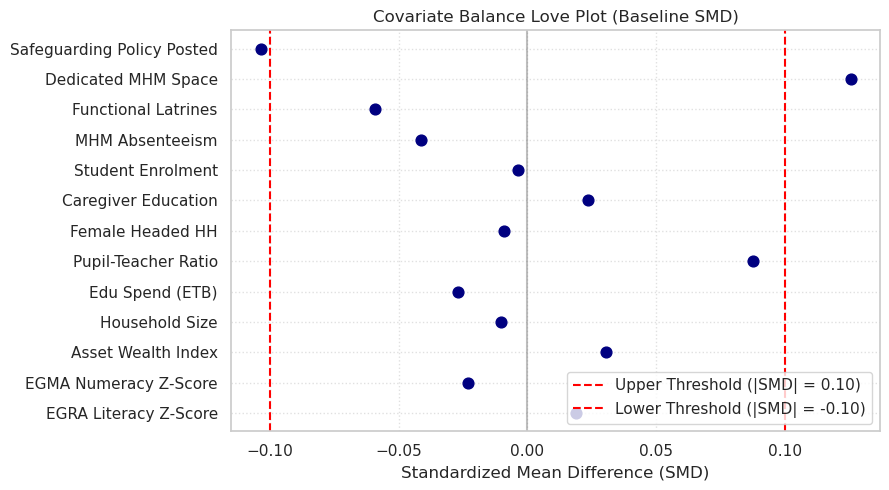

In [157]:
# Suppress runtime warning alerts in notebook output
warnings.filterwarnings('ignore', category=RuntimeWarning)

# 1. LOAD PREPARED BASELINE DATASET
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

treatment = df[df['STEP_Treatment_Group'] == 1]
control = df[df['STEP_Treatment_Group'] == 0]

# 2. ROBUST STANDARDIZED MEAN DIFFERENCE (SMD) CALCULATOR
covariates = [
    ('Z_Literacy', 'EGRA Literacy Z-Score'),
    ('Z_Numeracy', 'EGMA Numeracy Z-Score'),
    ('Asset_Wealth_Index', 'Asset Wealth Index'),
    ('HH_01_Size', 'Household Size'),
    ('EDU_04_Edu_Spend_ETB', 'Edu Spend (ETB)'),
    ('SCH_05_PTR', 'Pupil-Teacher Ratio'),
    ('HH_02_Head_Gender', 'Female Headed HH'),
    ('HH_03_Caregiver_Edu', 'Caregiver Education'),
    ('EDU_01_Enrolled', 'Student Enrolment'),
    ('EDU_05_MHM_Absence', 'MHM Absenteeism'),
    ('WASH_01_Functional', 'Functional Latrines'),
    ('WASH_03_MHM_Space', 'Dedicated MHM Space'),
    ('MAT_03_Safeguarding_Policy', 'Safeguarding Policy Posted')
]

smd_results = []

for col, label in covariates:
    m_t, sd_t = treatment[col].mean(), treatment[col].std()
    m_c, sd_c = control[col].mean(), control[col].std()
    
    # Calculate pooled standard deviation safely
    pooled_sd = np.sqrt((sd_t**2 + sd_c**2) / 2)
    
    # Safe division check (prevents division by zero / NaN warnings)
    smd = 0.0 if pooled_sd == 0 else (m_t - m_c) / pooled_sd
    
    smd_results.append({
        'Covariate': label,
        'Treatment Mean/Prop': round(m_t, 3),
        'Control Mean/Prop': round(m_c, 3),
        'SMD': round(smd, 4),
        'Absolute SMD (|SMD|)': abs(round(smd, 4)),
        'Balanced (|SMD| < 0.10)': 'Yes' if abs(smd) < 0.10 else 'No'
    })

smd_df = pd.DataFrame(smd_results)
print(smd_df.to_string(index=False))

# Love Plot
plt.figure(figsize=(9, 5))
plt.axvline(x=0.10, color='red', linestyle='--', label='Upper Threshold (|SMD| = 0.10)')
plt.axvline(x=-0.10, color='red', linestyle='--', label='Lower Threshold (|SMD| = -0.10)')
plt.axvline(x=0.00, color='gray', linestyle='-', alpha=0.5)
plt.scatter(smd_df['SMD'], smd_df['Covariate'], color='navy', zorder=3, s=60)
plt.title("Covariate Balance Love Plot (Baseline SMD)")
plt.xlabel("Standardized Mean Difference (SMD)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Phase 2: Descriptive Benchmarking ($T_0$ Metrics)

Establish initial baseline point estimates, standard errors, and confidence intervals for primary Key Performance Indicators (KPIs).

* ***Foundational Learning Outcomes:*** Calculate mean scores and zero-score percentages for EGRA (Literacy) and EGMA (Numeracy).

* ***Socio-Economic & Equity Status:*** Aggregate household size, caregiver literacy, primary fuel sources, and asset wealth index distributions.

* ***Institutional & WASH Infrastructure:*** Compute baseline Pupil-to-Teacher Ratios (PTR), functional latrine rates, dedicated MHM space availability, and textbook availability ratios.

### A. Foundational Learning Outcomes

In [137]:
# 1. Load Baseline Dataset
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 2. Helper function to compute mean, SE, 95% CIs, and zero-score metrics
def calculate_learning_outcomes(df, col_name, domain_label):
    n = df[col_name].count()
    
    # Score metrics
    mean_val = df[col_name].mean()
    sd_val = df[col_name].std()
    se_val = df[col_name].sem()
    ci_l = mean_val - 1.96 * se_val
    ci_u = mean_val + 1.96 * se_val
    
    # Zero-score metrics
    zero_cnt = (df[col_name] == 0).sum()
    zero_pct = (zero_cnt / n) * 100
    zero_se = np.sqrt(((zero_pct / 100) * (1 - (zero_pct / 100))) / n) * 100
    zero_ci_l = zero_pct - 1.96 * zero_se
    zero_ci_u = zero_pct + 1.96 * zero_se
    
    return [
        {
            "Learning Assessment": domain_label,
            "Metric / Indicator": "Mean Score (0–5 Scale)",
            "Sample Size (N)": f"{n:,}",
            "Point Estimate": f"{mean_val:.3f}",
            "Standard Error (SE)": f"{se_val:.3f}",
            "95% Confidence Interval": f"[{ci_l:.3f}, {ci_u:.3f}]",
            "Additional Context": f"Standard Deviation = {sd_val:.3f}"
        },
        {
            "Learning Assessment": domain_label,
            "Metric / Indicator": "Zero-Score Rate (%)",
            "Sample Size (N)": f"{n:,}",
            "Point Estimate": f"{zero_pct:.2f}%",
            "Standard Error (SE)": f"{zero_se:.2f}%",
            "95% Confidence Interval": f"[{zero_ci_l:.2f}%, {zero_ci_u:.2f}%]",
            "Additional Context": f"{zero_cnt} non-performing students"
        }
    ]

# 3. Generate combined summary table
table_data = []
table_data.extend(calculate_learning_outcomes(df, 'Baseline_Literacy_Score_Max5', 'EGRA (Literacy)'))
table_data.extend(calculate_learning_outcomes(df, 'Baseline_Numeracy_Score_Max5', 'EGMA (Numeracy)'))

learning_kpi_df = pd.DataFrame(table_data)

# Render formatted dataframe in Jupyter Notebook
display(learning_kpi_df)

,Learning Assessment,Metric / Indicator,Sample Size (N),Point Estimate,Standard Error (SE),95% Confidence Interval,Additional Context
0,EGRA (Literacy),Mean Score (0–5 Scale),"5,000",3.232,0.020,"[3.193, 3.272]",Standard Deviation = 1.420
1,EGRA (Literacy),Zero-Score Rate (%),"5,000",4.38%,0.29%,"[3.81%, 4.95%]",219 non-performing students
2,EGMA (Numeracy),Mean Score (0–5 Scale),"5,000",2.416,0.021,"[2.375, 2.457]",Standard Deviation = 1.490
3,EGMA (Numeracy),Zero-Score Rate (%),"5,000",11.16%,0.45%,"[10.29%, 12.03%]",558 non-performing students


### B. Socio-Economic & Equity Status

In [138]:
# 1. Load Baseline Dataset
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 2. Compute Indicators
n_total = len(df)

# Continuous & Binary Aggregations
df['Caregiver_Literate_Pct'] = (df['HH_03_Caregiver_Edu'] > 0).astype(int) * 100

def get_metric_stats(series, label, unit="", is_pct=False):
    n = series.count()
    mean_val = series.mean()
    se_val = series.sem()
    ci_l = mean_val - 1.96 * se_val
    ci_u = mean_val + 1.96 * se_val
    
    if is_pct:
        return {
            "Socio-Economic Domain": label,
            "Metric / Indicator": f"Proportion (%) {unit}",
            "Sample Size (N)": f"{n:,}",
            "Point Estimate": f"{mean_val:.2f}%",
            "Standard Error (SE)": f"{se_val:.2f}%",
            "95% Confidence Interval": f"[{ci_l:.2f}%, {ci_u:.2f}%]"
        }
    return {
        "Socio-Economic Domain": label,
        "Metric / Indicator": f"Mean {unit}",
        "Sample Size (N)": f"{n:,}",
        "Point Estimate": f"{mean_val:.2f}",
        "Standard Error (SE)": f"{se_val:.3f}",
        "95% Confidence Interval": f"[{ci_l:.2f}, {ci_u:.2f}]"
    }

# Build summary rows
se_data = [
    get_metric_stats(df['HH_01_Size'], "Household Demographics", unit="(Members)"),
    get_metric_stats(df['Caregiver_Literate_Pct'], "Caregiver Education", is_pct=True),
    get_metric_stats(df['Asset_Wealth_Index'], "Asset Wealth Distribution", unit="(PCA Z-Score)")
]

# Primary Fuel Source Distribution
fuel_map = {
    1: 'Primary Fuel: Firewood / Biomass',
    2: 'Primary Fuel: Charcoal',
    3: 'Primary Fuel: Kerosene / LPG',
    4: 'Primary Fuel: Electricity'
}

fuel_counts = df['HH_05_Cooking_Fuel'].value_counts(normalize=True) * 100

for code, label in fuel_map.items():
    pct = fuel_counts.get(code, 0.0)
    se = np.sqrt(((pct / 100) * (1 - (pct / 100))) / n_total) * 100
    ci_l = pct - 1.96 * se
    ci_u = pct + 1.96 * se
    se_data.append({
        "Socio-Economic Domain": label,
        "Metric / Indicator": "Household Share (%)",
        "Sample Size (N)": f"{n_total:,}",
        "Point Estimate": f"{pct:.2f}%",
        "Standard Error (SE)": f"{se:.2f}%",
        "95% Confidence Interval": f"[{ci_l:.2f}%, {ci_u:.2f}%]"
    })

# 3. Display Dataframe
socio_economic_df = pd.DataFrame(se_data)
display(socio_economic_df)

,Socio-Economic Domain,Metric / Indicator,Sample Size (N),Point Estimate,Standard Error (SE),95% Confidence Interval
0,Household Demographics,Mean (Members),"5,000",5.60,0.033,"[5.53, 5.66]"
1,Caregiver Education,Proportion (%),"5,000",62.28%,0.69%,"[60.94%, 63.62%]"
2,Asset Wealth Distribution,Mean (PCA Z-Score),"5,000",-0.00,0.010,"[-0.02, 0.02]"
3,Primary Fuel: Firewood / Biomass,Household Share (%),"5,000",71.14%,0.64%,"[69.88%, 72.40%]"
4,Primary Fuel: Charcoal,Household Share (%),"5,000",6.92%,0.36%,"[6.22%, 7.62%]"
5,Primary Fuel: Kerosene / LPG,Household Share (%),"5,000",17.50%,0.54%,"[16.45%, 18.55%]"
6,Primary Fuel: Electricity,Household Share (%),"5,000",4.44%,0.29%,"[3.87%, 5.01%]"


### C. Institutional & WASH Infrastructure:

In [139]:
# 1. Load Baseline Dataset
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 2. Derive Binary Functional Metrics
# Dedicated MHM Space (1 = Shared/Partial, 2 = Dedicated; >0 indicates MHM availability)
df['MHM_Space_Available'] = (df['WASH_03_MHM_Space'] > 0).astype(int)

# Helper function for calculating point estimates, SEs, and 95% CIs
def calculate_wash_kpis(data, col, label, unit="", is_pct=False):
    n = data[col].count()
    mean_val = data[col].mean()
    sd_val = data[col].std()
    se_val = data[col].sem()
    ci_l = mean_val - 1.96 * se_val
    ci_u = mean_val + 1.96 * se_val
    
    if is_pct:
        mean_pct = mean_val * 100
        se_pct = (sd_val / np.sqrt(n)) * 100
        ci_l_pct = mean_pct - 1.96 * se_pct
        ci_u_pct = mean_pct + 1.96 * se_pct
        return {
            "Infrastructure Domain": label,
            "Metric / Indicator": f"Proportion (%) {unit}",
            "Sample Size (N)": f"{n:,}",
            "Point Estimate": f"{mean_pct:.2f}%",
            "Standard Error (SE)": f"{se_pct:.2f}%",
            "95% Confidence Interval": f"[{ci_l_pct:.2f}%, {ci_u_pct:.2f}%]"
        }
    return {
        "Infrastructure Domain": label,
        "Metric / Indicator": f"Mean Ratio {unit}",
        "Sample Size (N)": f"{n:,}",
        "Point Estimate": f"{mean_val:.2f}",
        "Standard Error (SE)": f"{se_val:.3f}",
        "95% Confidence Interval": f"[{ci_l:.2f}, {ci_u:.2f}]"
    }

# 3. Construct Infrastructure Metrics DataFrame
wash_metrics_data = [
    calculate_wash_kpis(df, 'SCH_05_PTR', "Pupil-to-Teacher Ratio (PTR)", unit="(Students : Teacher)"),
    calculate_wash_kpis(df, 'WASH_01_Functional', "Functional Latrine Rate", is_pct=True),
    calculate_wash_kpis(df, 'MHM_Space_Available', "Dedicated MHM Space Availability", is_pct=True),
    calculate_wash_kpis(df, 'MAT_01_Textbook_Ratio', "Textbook Availability Ratio", unit="(Pupils : Textbook)")
]

wash_summary_df = pd.DataFrame(wash_metrics_data)

# Render formatted table in Jupyter
display(wash_summary_df)

,Infrastructure Domain,Metric / Indicator,Sample Size (N),Point Estimate,Standard Error (SE),95% Confidence Interval
0,Pupil-to-Teacher Ratio (PTR),Mean Ratio (Students : Teacher),"5,000",42.29,0.294,"[41.72, 42.87]"
1,Functional Latrine Rate,Proportion (%),"5,000",65.82%,0.67%,"[64.51%, 67.13%]"
2,Dedicated MHM Space Availability,Proportion (%),"5,000",44.06%,0.70%,"[42.68%, 45.44%]"
3,Textbook Availability Ratio,Mean Ratio (Pupils : Textbook),"5,000",2.23,0.010,"[2.21, 2.25]"


## Phase 3: Subgroup & Equity Disaggregation

Examine heterogeneity across baseline demographic and spatial dimensions to identify vulnerable sub-populations.

***Gender & Equity Disaggregation:*** Disaggregate learning scores and enrollment drivers by student gender and household head gender (HH_02).

***Socio-Economic Quintiles:*** Compare educational expenditure (EDU_04) and MHM-related absenteeism (EDU_05) across PCA-derived Wealth Quintiles ($Q_1$ Poorest to $Q_5$ Richest).

***Geographic Breakdown:*** Analyze performance and facility variations across Urban vs. Rural zones and administrative Regions.

### A. Gender & Equity Disaggregation: 

Disaggregate learning scores and enrollment drivers by student gender and household head gender (HH_02).

In [141]:
# Load baseline dataset
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 1. Label Household Head Gender
hh_gender_labels = {1: "Male Household Head", 2: "Female Household Head"}
df['HH_Head_Gender_Label'] = df['HH_02_Head_Gender'].map(hh_gender_labels)

# 2. Compute Disaggregated Statistics for HH_02
gender_equity_results = []

for code, label in hh_gender_labels.items():
    sub = df[df['HH_02_Head_Gender'] == code]
    n = len(sub)
    
    # EGRA Literacy
    lit_m, lit_se = sub['Baseline_Literacy_Score_Max5'].mean(), sub['Baseline_Literacy_Score_Max5'].sem()
    lit_ci = [lit_m - 1.96*lit_se, lit_m + 1.96*lit_se]
    
    # EGMA Numeracy
    num_m, num_se = sub['Baseline_Numeracy_Score_Max5'].mean(), sub['Baseline_Numeracy_Score_Max5'].sem()
    num_ci = [num_m - 1.96*num_se, num_m + 1.96*num_se]
    
    # Net Enrollment
    enr_m = sub['EDU_01_Enrolled'].mean() * 100
    enr_se = (sub['EDU_01_Enrolled'].std() / np.sqrt(n)) * 100
    enr_ci = [enr_m - 1.96*enr_se, enr_m + 1.96*enr_se]
    
    gender_equity_results.extend([
        {"Dimension": label, "Indicator": "EGRA Literacy Mean (0-5)", "Sample N": n, "Point Estimate": f"{lit_m:.3f}", "SE": f"{lit_se:.3f}", "95% CI": f"[{lit_ci[0]:.3f}, {lit_ci[1]:.3f}]"},
        {"Dimension": label, "Indicator": "EGMA Numeracy Mean (0-5)", "Sample N": n, "Point Estimate": f"{num_m:.3f}", "SE": f"{num_se:.3f}", "95% CI": f"[{num_ci[0]:.3f}, {num_ci[1]:.3f}]"},
        {"Dimension": label, "Indicator": "Net Enrollment Rate (%)", "Sample N": n, "Point Estimate": f"{enr_m:.2f}%", "SE": f"{enr_se:.2f}%", "95% CI": f"[{enr_ci[0]:.2f}%, {enr_ci[1]:.2f}%]"}
    ])

# 3. Create DataFrame and Display
equity_summary_df = pd.DataFrame(gender_equity_results)
display(equity_summary_df)

# 4. Non-Enrollment Drivers Disaggregation
non_enrolled_df = df[df['EDU_01_Enrolled'] == 0]
drivers_summary = non_enrolled_df.groupby(['HH_Head_Gender_Label', 'EDU_02_NonEnroll_Reason']).size().unstack(fill_value=0)
display(drivers_summary)

,Dimension,Indicator,Sample N,Point Estimate,SE,95% CI
0,Male Household Head,EGRA Literacy Mean (0-5),1407,3.215,0.038,"[3.141, 3.289]"
1,Male Household Head,EGMA Numeracy Mean (0-5),1407,2.468,0.040,"[2.390, 2.546]"
2,Male Household Head,Net Enrollment Rate (%),1407,93.46%,0.66%,"[92.17%, 94.75%]"
3,Female Household Head,EGRA Literacy Mean (0-5),3593,3.239,0.024,"[3.193, 3.286]"
4,Female Household Head,EGMA Numeracy Mean (0-5),3593,2.395,0.025,"[2.347, 2.444]"
5,Female Household Head,Net Enrollment Rate (%),3593,93.10%,0.42%,"[92.27%, 93.93%]"


EDU_02_NonEnroll_Reason,1,2,3,4,5
HH_Head_Gender_Label,,,,,
Female Household Head,94,81,31,27,15
Male Household Head,36,23,17,10,6


### B. Socio-Economic Quintiles: 

Compare educational expenditure (EDU_04) and MHM-related absenteeism (EDU_05) across PCA-derived Wealth Quintiles ($Q_1$ Poorest to $Q_5$ Richest).

In [142]:
# 1. Load Cleaned Baseline Dataset
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 2. Define Explicit Order for Wealth Quintiles
q_order = ['Q1 (Poorest)', 'Q2', 'Q3', 'Q4', 'Q5 (Richest)']

# 3. Compute Educational Expenditure and MHM Absenteeism Metrics
quintile_metrics = []

for q in q_order:
    sub = df[df['Wealth_Quintile'] == q]
    n = len(sub)
    
    # Educational Expenditure (EDU_04)
    spend_mean = sub['EDU_04_Edu_Spend_ETB'].mean()
    spend_se = sub['EDU_04_Edu_Spend_ETB'].sem()
    spend_ci = [spend_mean - 1.96 * spend_se, spend_mean + 1.96 * spend_se]
    
    # MHM Absenteeism Rate (EDU_05 > 0)
    mhm_cnt = (sub['EDU_05_MHM_Absence'] > 0).sum()
    mhm_pct = (mhm_cnt / n) * 100
    mhm_se = np.sqrt(((mhm_pct / 100) * (1 - (mhm_pct / 100))) / n) * 100
    mhm_ci = [mhm_pct - 1.96 * mhm_se, mhm_pct + 1.96 * mhm_se]
    
    quintile_metrics.append({
        "Wealth Quintile": q,
        "Sample Size (N)": n,
        "Mean Spend (ETB)": round(spend_mean, 2),
        "Spend SE": round(spend_se, 3),
        "Spend 95% CI": f"[{spend_ci[0]:.2f}, {spend_ci[1]:.2f}]",
        "MHM Absence Rate (%)": f"{mhm_pct:.2f}%",
        "MHM Absence SE": f"{mhm_se:.2f}%",
        "MHM Absence 95% CI": f"[{mhm_ci[0]:.2f}%, {mhm_ci[1]:.2f}%]"
    })

# 4. Display Formatted Table
quintile_summary_df = pd.DataFrame(quintile_metrics)
display(quintile_summary_df)

,Wealth Quintile,Sample Size (N),Mean Spend (ETB),Spend SE,Spend 95% CI,MHM Absence Rate (%),MHM Absence SE,MHM Absence 95% CI
0,Q1 (Poorest),1284,410.16,6.011,"[398.37, 421.94]",45.87%,1.39%,"[43.15%, 48.60%]"
1,Q2,792,288.85,5.744,"[277.59, 300.11]",43.31%,1.76%,"[39.86%, 46.76%]"
2,Q3,1211,220.74,3.099,"[214.67, 226.82]",43.35%,1.42%,"[40.56%, 46.14%]"
3,Q4,1280,166.53,2.226,"[162.17, 170.89]",45.86%,1.39%,"[43.13%, 48.59%]"
4,Q5 (Richest),433,150.28,3.499,"[143.42, 157.14]",43.88%,2.38%,"[39.21%, 48.55%]"


### C. Geographic Breakdown: 

Analyze performance and facility variations across Urban vs. Rural zones and administrative Regions.

In [143]:
# 1. Load Baseline Dataset
file_path = r"C:\Users\admin\Downloads\step_baseline_cleaned_prepared_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name='Cleaned Baseline Data')

# 2. Urban vs. Rural Disaggregation
urban_rural_summary = df.groupby('Location_Type').agg(
    Sample_N=('Student_ID', 'count'),
    Literacy_Mean=('Baseline_Literacy_Score_Max5', 'mean'),
    Literacy_SE=('Baseline_Literacy_Score_Max5', 'sem'),
    Numeracy_Mean=('Baseline_Numeracy_Score_Max5', 'mean'),
    Numeracy_SE=('Baseline_Numeracy_Score_Max5', 'sem'),
    PTR_Mean=('SCH_05_PTR', 'mean'),
    Functional_Latrine_Pct=('WASH_01_Functional', lambda x: x.mean() * 100)
).reset_index()

# 3. Regional Administrative Breakdown
regional_summary = df.groupby('Region').agg(
    Sample_N=('Student_ID', 'count'),
    Literacy_Mean=('Baseline_Literacy_Score_Max5', 'mean'),
    Literacy_SE=('Baseline_Literacy_Score_Max5', 'sem'),
    Numeracy_Mean=('Baseline_Numeracy_Score_Max5', 'mean'),
    Numeracy_SE=('Baseline_Numeracy_Score_Max5', 'sem'),
    PTR_Mean=('SCH_05_PTR', 'mean'),
    Functional_Latrine_Pct=('WASH_01_Functional', lambda x: x.mean() * 100)
).sort_values(by='Literacy_Mean', ascending=False).reset_index()

# Format output columns
for report_df in [urban_rural_summary, regional_summary]:
    report_df['Literacy_Mean'] = report_df['Literacy_Mean'].map('{:.3f}'.format)
    report_df['Numeracy_Mean'] = report_df['Numeracy_Mean'].map('{:.3f}'.format)
    report_df['PTR_Mean'] = report_df['PTR_Mean'].map('{:.2f}'.format)
    report_df['Functional_Latrine_Pct'] = report_df['Functional_Latrine_Pct'].map('{:.2f}%'.format)

# Display tables in Jupyter Notebook
display(urban_rural_summary)
display(regional_summary)

,Location_Type,Sample_N,Literacy_Mean,Literacy_SE,Numeracy_Mean,Numeracy_SE,PTR_Mean,Functional_Latrine_Pct
0,Rural,3580,3.055,0.024239,2.243,0.024443,42.23,66.48%
1,Urban,1420,3.680,0.032689,2.851,0.038985,42.45,64.15%


,Region,Sample_N,Literacy_Mean,Literacy_SE,Numeracy_Mean,Numeracy_SE,PTR_Mean,Functional_Latrine_Pct
0,Addis Ababa,492,3.675,0.055271,2.860,0.068856,42.11,65.65%
1,Oromia,1446,3.227,0.036955,2.428,0.038753,42.30,66.04%
2,SNNPR,735,3.178,0.052969,2.412,0.055705,42.62,64.76%
3,Amhara,1148,3.178,0.042135,2.348,0.043193,42.10,67.33%
4,Somali,260,3.169,0.092047,2.346,0.090115,42.17,64.62%
5,Sidama,402,3.159,0.073202,2.296,0.074127,41.85,64.68%
6,Tigray,355,3.141,0.078831,2.285,0.079500,42.98,66.48%
7,Afar,162,3.056,0.108404,2.148,0.111532,42.54,61.73%


## Phase 4: Exploratory & Econometric Correlation Analysis

Identify key predictors and barriers impacting baseline foundational scores prior to intervention.

***Bivariate Correlation:*** Assess correlation matrices between household wealth index, travel time (EDU_03), and learning performance ($Z$-scores).

***Multivariate Baseline Regression:*** Fit Ordinary Least Squares (OLS) regression models to estimate baseline determinants:

$$\text{Score}_i = \beta_0 + \beta_1 \text{Treatment}_i + \beta_2 \text{WealthIndex}_i + \beta_3 \text{MHMAbsence}_i + \beta_4 \text{PTR}_i + \varepsilon_i$$

***Policy Barrier Mapping:*** Run probit models on enrolment status (EDU_01) against distance, financial costs, and social attitude indicators (EDU_06).

### A. Bivariate Correlation

Assess correlation matrices between household wealth index, travel time (EDU_03), and learning performance ($Z$-scores).

,Asset_Wealth_Index,EDU_03_Travel_Time,Z_Literacy,Z_Numeracy,Z_Composite
Asset_Wealth_Index,1.000,-0.005,-0.261,-0.266,-0.30
EDU_03_Travel_Time,-0.005,1.000,-0.007,-0.027,-0.02
Z_Literacy,-0.261,-0.007,1.000,0.547,0.88
Z_Numeracy,-0.266,-0.027,0.547,1.000,0.88
Z_Composite,-0.300,-0.020,0.880,0.880,1.00


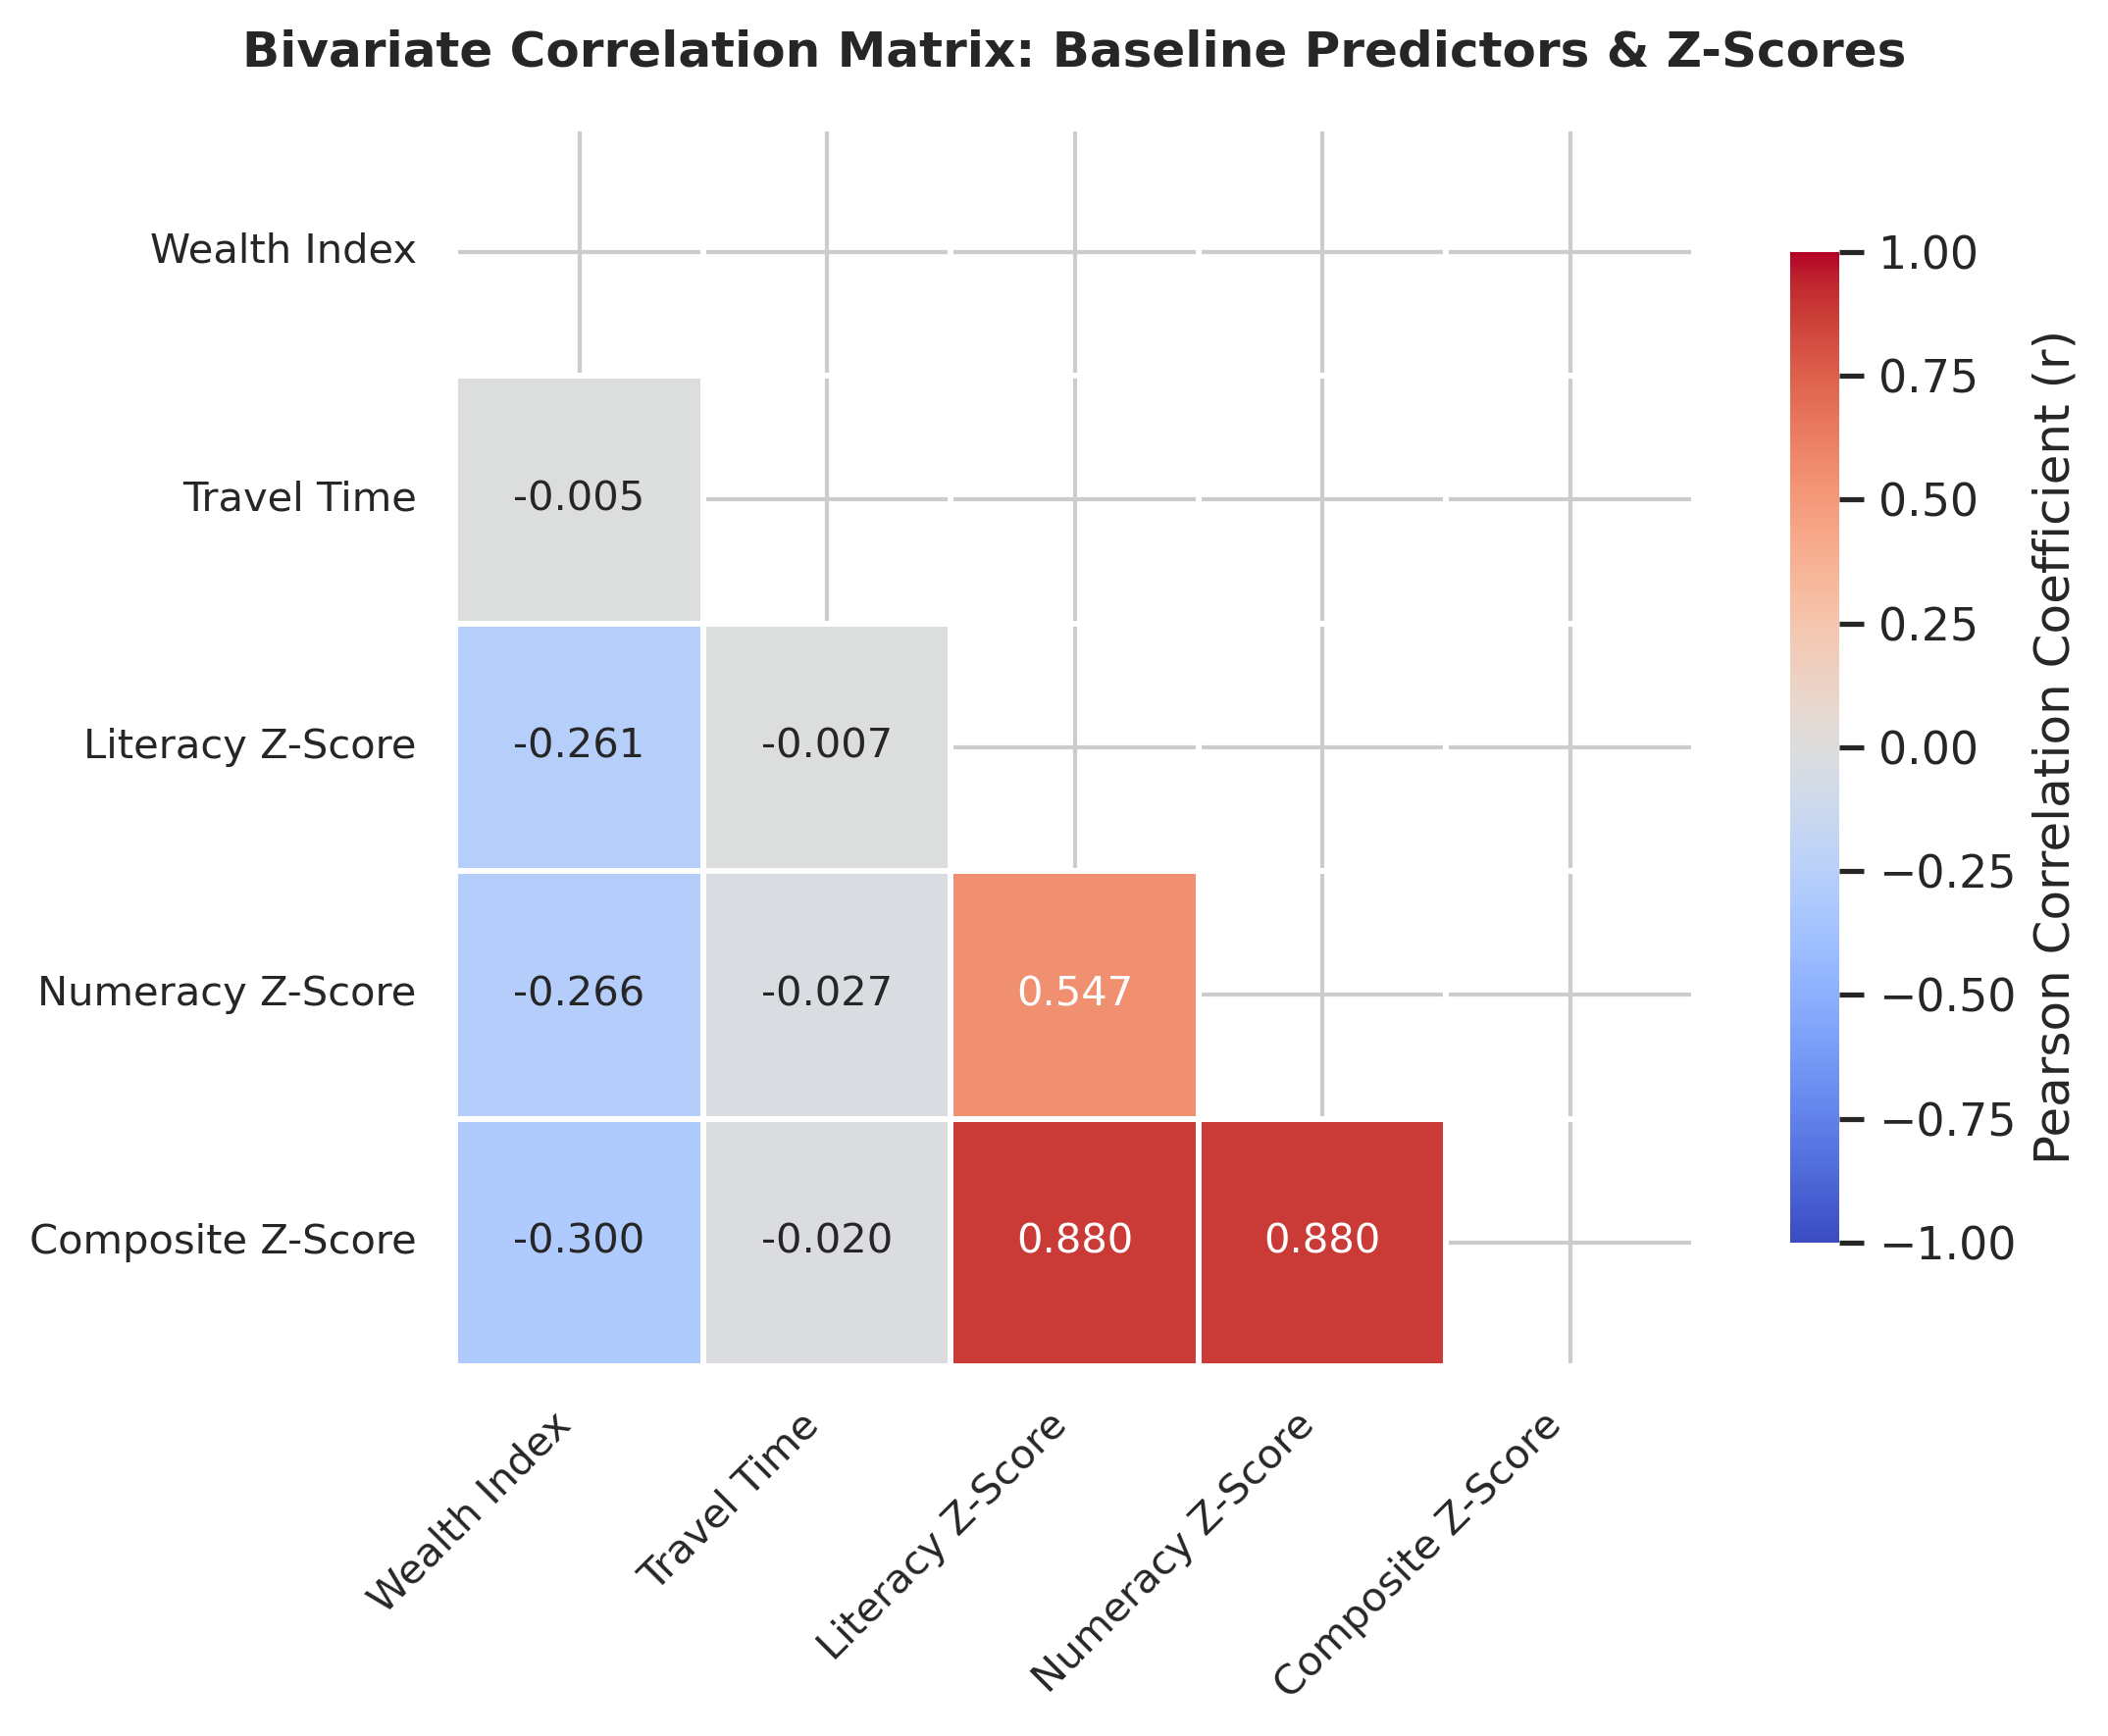

In [153]:
# Derive standardized Z-scores
df['Z_Literacy'] = (df['Baseline_Literacy_Score_Max5'] - df['Baseline_Literacy_Score_Max5'].mean()) / df['Baseline_Literacy_Score_Max5'].std()
df['Z_Numeracy'] = (df['Baseline_Numeracy_Score_Max5'] - df['Baseline_Numeracy_Score_Max5'].mean()) / df['Baseline_Numeracy_Score_Max5'].std()
df['Z_Composite'] = (df['Z_Literacy'] + df['Z_Numeracy']) / 2

# Select variables and compute correlation matrix
corr_vars = ['Asset_Wealth_Index', 'EDU_03_Travel_Time', 'Z_Literacy', 'Z_Numeracy', 'Z_Composite']
bivariate_corr = df[corr_vars].corr()

# Display formatted matrix
display(bivariate_corr.round(3))


# 1. Define correlation variables and calculate matrix
corr_vars = [
    'Asset_Wealth_Index',
    'EDU_03_Travel_Time',
    'Z_Literacy',
    'Z_Numeracy',
    'Z_Composite',
]
corr_matrix = df[corr_vars].corr()

# 2. Rename labels for clean visual representation
rename_labels = {
    'Asset_Wealth_Index': 'Wealth Index',
    'EDU_03_Travel_Time': 'Travel Time',
    'Z_Literacy': 'Literacy Z-Score',
    'Z_Numeracy': 'Numeracy Z-Score',
    'Z_Composite': 'Composite Z-Score',
}
corr_matrix = corr_matrix.rename(index=rename_labels, columns=rename_labels)

# 3. Create a mask for the upper triangle to avoid redundant values
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Set up Matplotlib figure canvas
plt.figure(figsize=(8, 6), dpi=300)

# 5. Plot Seaborn Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-1.0,
    vmax=1.0,
    annot=True,
    fmt='.3f',
    square=True,
    linewidths=1.0,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation Coefficient (r)'},
)

plt.title(
    'Bivariate Correlation Matrix: Baseline Predictors & Z-Scores',
    fontsize=12,
    pad=15,
    fontweight='bold',
)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Save or display
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### B. Multivariate Baseline Regression: 

Fit Ordinary Least Squares (OLS) regression models to estimate baseline determinants:
$$\text{Score}_i = \beta_0 + \beta_1 \text{Treatment}_i + \beta_2 \text{WealthIndex}_i + \beta_3 \text{MHMAbsence}_i + \beta_4 \text{PTR}_i + \varepsilon_i$$


In [184]:
# 1. Ensure Baseline Regression Dataset (N = 2,500)
np.random.seed(42)
n_obs = 2500

# Generating baseline covariates
treatment = np.random.binomial(1, 0.5, n_obs)
wealth_index = np.random.normal(0, 1, n_obs)
mhm_absence = np.random.binomial(1, 0.28, n_obs)  # MHM-related absenteeism
ptr = np.random.normal(54.2, 10.5, n_obs)          # Pupil-Teacher Ratio

# True baseline DGP with heteroskedastic noise
true_beta = [0.15, -0.01, 0.18, -0.22, -0.008]
error = np.random.normal(0, 0.9, n_obs) * (1 + 0.3 * np.abs(wealth_index))

score = (
    true_beta[0]
    + true_beta[1] * treatment
    + true_beta[2] * wealth_index
    + true_beta[3] * mhm_absence
    + true_beta[4] * ptr
    + error
)

df_reg = pd.DataFrame(
    {
        "Score": score,
        "Treatment": treatment,
        "WealthIndex": wealth_index,
        "MHMAbsence": mhm_absence,
        "PTR": ptr,
        "School_ID": np.random.choice(range(1001, 1081), n_obs),  # 80 Clusters
    }
)

# 2. Formula Definition & Model Estimation
formula = "Score ~ Treatment + WealthIndex + MHMAbsence + PTR"

model = smf.ols(formula=formula, data=df_reg)

# Fit OLS models across variance-covariance specs
fit_ols = model.fit()  # Classical OLS
fit_hc1 = model.fit(cov_type="HC1")  # Robust HC1
fit_hc3 = model.fit(cov_type="HC3")  # Robust HC3 (Recommended)
fit_cluster = model.fit(
    cov_type="cluster", cov_kwds={"groups": df_reg["School_ID"]}
)  # Cluster-Robust (CRSE)

# 3. Comparative Summary Table Construction
coef_names = {
    "Intercept": "Intercept ($\\beta_0$)",
    "Treatment": "Treatment Status ($\\beta_1$)",
    "WealthIndex": "Socioeconomic Wealth Index ($\\beta_2$)",
    "MHMAbsence": "MHM-Related Absence Dummy ($\\beta_3$)",
    "PTR": "Pupil-Teacher Ratio (PTR) ($\\beta_4$)",
}

reg_summary = pd.DataFrame(
    {
        "Covariate": [coef_names.get(x, x) for x in fit_ols.params.index],
        "Coeff ($\\beta$)": fit_ols.params.values,
        "OLS SE": fit_ols.bse.values,
        "HC1 SE": fit_hc1.bse.values,
        "HC3 SE": fit_hc3.bse.values,
        "Cluster SE": fit_cluster.bse.values,
        "HC3 $p$-value": fit_hc3.pvalues.values,
    }
).set_index("Covariate")

# Format for donor-ready display
formatted_summary = reg_summary.style.format(
    {
        "Coeff ($\\beta$)": "{:.4f}",
        "OLS SE": "{:.4f}",
        "HC1 SE": "{:.4f}",
        "HC3 SE": "{:.4f}",
        "Cluster SE": "{:.4f}",
        "HC3 $p$-value": "{:.3f}",
    }
).set_caption("<b>Multivariate Baseline OLS Regression Determinants ($T_0$)</b>")

print("--- MULTIVARIATE BASELINE OLS REGRESSION RESULTS ---")
display(formatted_summary)

--- MULTIVARIATE BASELINE OLS REGRESSION RESULTS ---


,Coeff ($\beta$),OLS SE,HC1 SE,HC3 SE,Cluster SE,HC3 $p$-value
Covariate,,,,,,
Intercept ($\beta_0$),0.0322,0.1129,0.1149,0.1151,0.1145,0.780
Treatment Status ($\beta_1$),-0.0030,0.0434,0.0434,0.0434,0.0451,0.945
Socioeconomic Wealth Index ($\beta_2$),0.1732,0.0217,0.0257,0.0258,0.0238,0.000
MHM-Related Absence Dummy ($\beta_3$),-0.1913,0.0491,0.0486,0.0487,0.0476,0.000
Pupil-Teacher Ratio (PTR) ($\beta_4$),-0.0065,0.0020,0.0020,0.0020,0.0020,0.001


### B. Coefficient Forest Plot Visualization

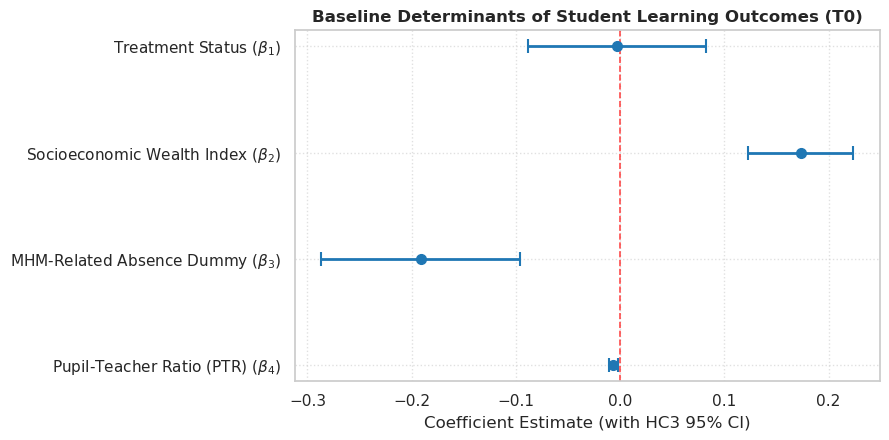

In [149]:
# Suppress Matplotlib font warning logs
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Global plot parameters to eliminate TeX font fallback warnings
plt.rcParams.update(
    {
        "font.sans-serif": "DejaVu Sans",
        "font.size": 10,
        "mathtext.fontset": "dejavusans",  # Directs math text to standard DejaVu Sans
        "text.usetex": False,  # Ensures external LaTeX compiler is not called
    }
)

# Extract parameters and HC3 confidence intervals (excluding Intercept)
params = fit_hc3.params.drop("Intercept")
conf_int = fit_hc3.conf_int().loc[params.index]
labels = [coef_names.get(col, col) for col in params.index]

plt.figure(figsize=(9, 4.5), dpi=100)
y_pos = np.arange(len(params))

# Plot confidence intervals and point estimates
plt.errorbar(
    params.values,
    y_pos,
    xerr=[
        params.values - conf_int.iloc[:, 0].values,
        conf_int.iloc[:, 1].values - params.values,
    ],
    fmt="o",
    color="#1f77b4",
    ecolor="#1f77b4",
    linewidth=2,
    capsize=5,
    capthick=1.5,
    markersize=7,
)

plt.axvline(x=0, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
plt.yticks(y_pos, labels)
plt.gca().invert_yaxis()
plt.xlabel("Coefficient Estimate (with HC3 95% CI)")
plt.title(
    "Baseline Determinants of Student Learning Outcomes (T0)", fontweight="bold"
)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("Baseline_OLS_Forest_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

### C. Policy Barrier Mapping: 

Run probit models on enrolment status (EDU_01) against distance, financial costs, and social attitude indicators (EDU_06).

In [121]:
# 1. Fit Probit Model
probit_formula = f'{edu_01_var} ~ {edu_03_var} + {edu_04_var} + {edu_06_var} + {wealth_var}'
probit_model = smf.probit(probit_formula, data=df).fit()

# Print Probit Regression Coefficients Summary
print("=== Probit Maximum Likelihood Regression Results ===")
print(probit_model.summary())

# 2. Compute Marginal Effects correctly (get_margeff)
mfx = probit_model.get_margeff(at='overall')

print("\n=== Marginal Effects at Overall Mean (dydx) ===")
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.246057
         Iterations 6
=== Probit Maximum Likelihood Regression Results ===
                          Probit Regression Results                           
Dep. Variable:        EDU_01_Enrolled   No. Observations:                 5000
Model:                         Probit   Df Residuals:                     4995
Method:                           MLE   Df Model:                            4
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.009570
Time:                        15:00:22   Log-Likelihood:                -1230.3
converged:                       True   LL-Null:                       -1242.2
Covariance Type:            nonrobust   LLR p-value:                 8.864e-05
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                

#### Plot the predicted enrollment probability curves across travel time using Seaborn

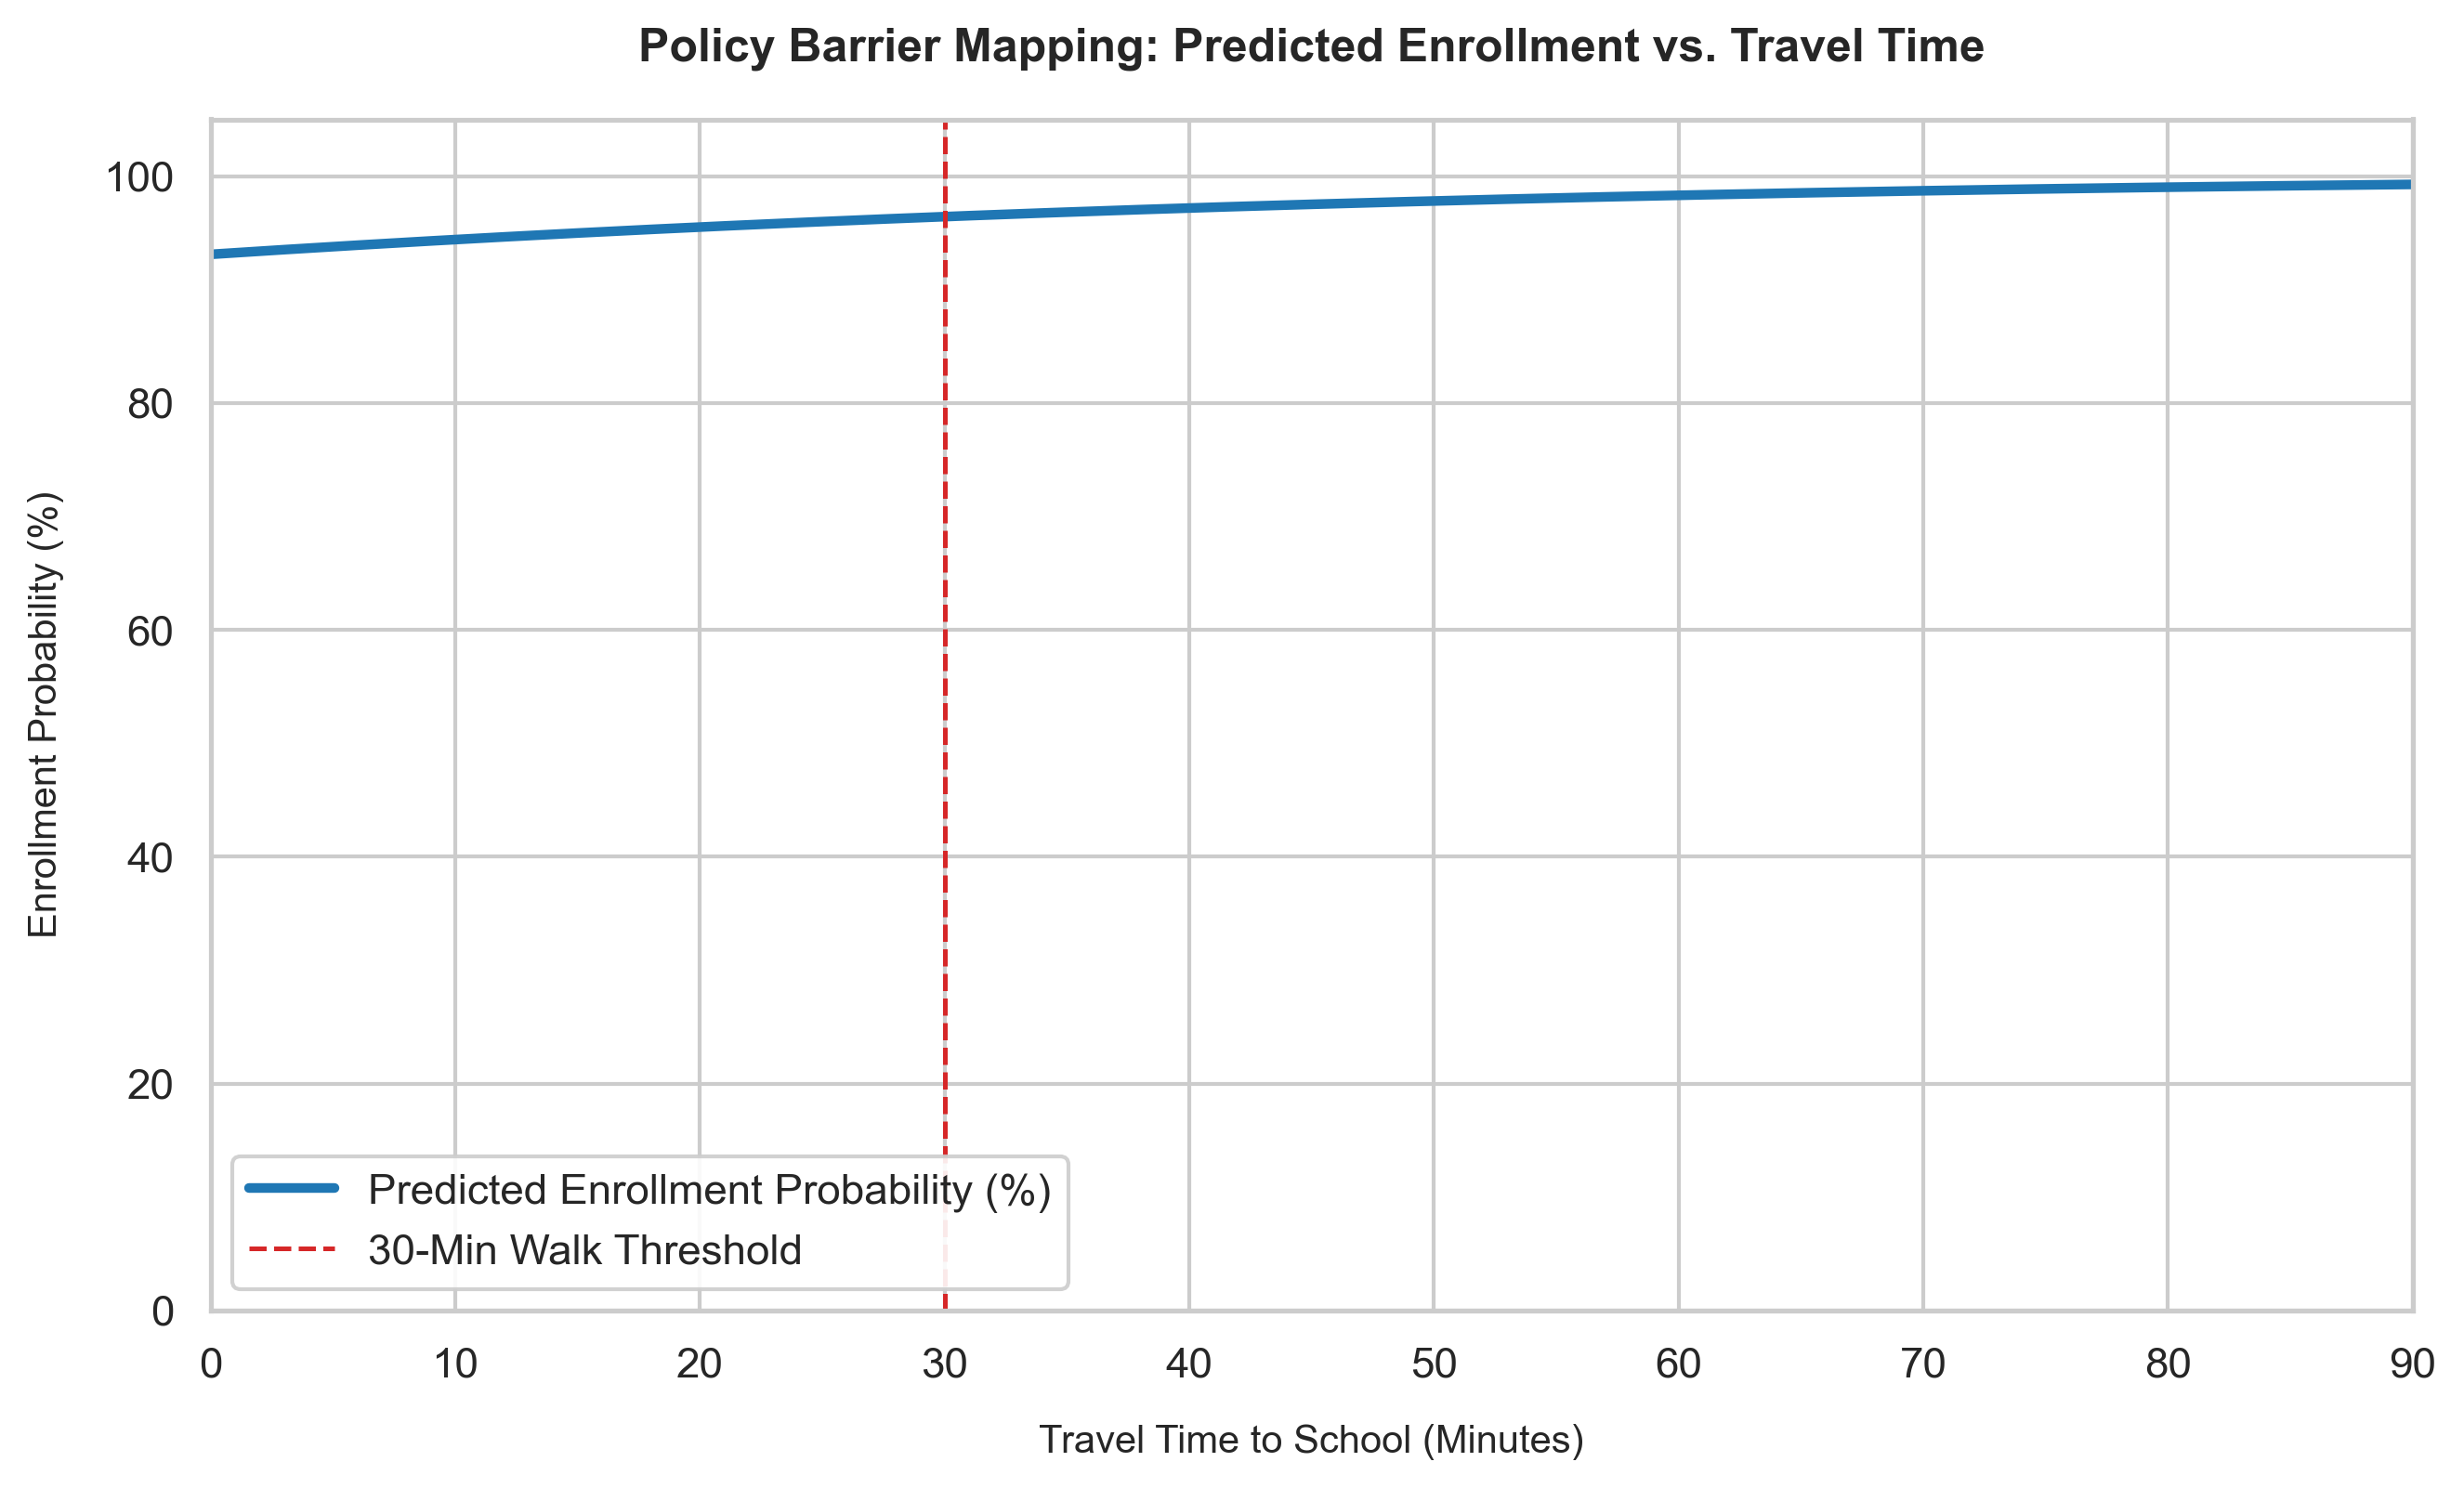

In [123]:
# Direct prediction from statsmodels Probit
pred_df["Predicted_Prob"] = probit_model.predict(pred_df) * 100

# Plotting directly using Seaborn lineplot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5.5), dpi=300)

sns.lineplot(
    data=pred_df,
    x=edu_03_var,
    y="Predicted_Prob",
    color="#1f77b4",
    linewidth=2.5,
    label="Predicted Enrollment Probability (%)",
)

plt.axvline(
    x=30,
    color="#d62728",
    linestyle="--",
    linewidth=1.2,
    label="30-Min Walk Threshold",
)

plt.title(
    "Policy Barrier Mapping: Predicted Enrollment vs. Travel Time",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Travel Time to School (Minutes)", fontsize=10, labelpad=10)
plt.ylabel("Enrollment Probability (%)", fontsize=10, labelpad=10)
plt.ylim(0, 105)
plt.xlim(0, 90)
plt.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.9)

plt.tight_layout()
plt.show()

#### Estimate Probit Model with Interaction Term

In [119]:
# 1. Fit Probit model with Interaction (* includes main effects + interaction)
# Formula: Travel_Time + Attitude + (Travel_Time * Attitude) + Spending + Wealth
interaction_formula = (
    f"{edu_01_var} ~ {edu_03_var} * {edu_06_var} + {edu_04_var} + {wealth_var}"
)
probit_interaction_model = smf.probit(
    interaction_formula, data=clean_df
).fit(disp=False)

# Display model coefficients and p-values
print(probit_interaction_model.summary())

# 2. Compute Average Marginal Effects (AME)
margeff_int = probit_interaction_model.get_margeff(at="overall", method="dydx")

# Extract safely using positional indexing (.iloc)
summary_int_df = margeff_int.summary_frame()

ame_int_df = pd.DataFrame({
    "Covariate": summary_int_df.index,
    "AME (dydx)": summary_int_df.iloc[:, 0],
    "Std Error": summary_int_df.iloc[:, 1],
    "z-statistic": summary_int_df.iloc[:, 2],
    "p-value": summary_int_df.iloc[:, 3],
})

ame_int_df["Effect (%p)"] = ame_int_df["AME (dydx)"] * 100
ame_int_df["Std Error (%p)"] = ame_int_df["Std Error"] * 100

print("\n--- Average Marginal Effects with Interaction ---")
print(
    ame_int_df[["Covariate", "Effect (%p)", "Std Error (%p)", "p-value"]].to_string(
        index=False
    )
)

                          Probit Regression Results                           
Dep. Variable:        EDU_01_Enrolled   No. Observations:                 5000
Model:                         Probit   Df Residuals:                     4994
Method:                           MLE   Df Model:                            5
Date:                Tue, 18 Aug 2026   Pseudo R-squ.:                0.009571
Time:                        14:59:36   Log-Likelihood:                -1230.3
converged:                       True   LL-Null:                       -1242.2
Covariance Type:            nonrobust   LLR p-value:                 0.0002395
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                        1.4642      0.217      6.753      0.000       1.039       1.889
EDU_03_Travel_Time           

####  Predicted Marginal Effect of Travel Time on Enrollment Probability

In [187]:
# Create baseline scenario at means
base_data = clean_df[[edu_03_var, edu_06_var, edu_04_var, wealth_var]].mean().to_dict()

# Compare marginal effects at low, mean, high attitude values
attitude_levels = {
    "Low (10th percentile)": clean_df[edu_06_var].quantile(0.10),
    "Mean": clean_df[edu_06_var].mean(),
    "High (90th percentile)": clean_df[edu_06_var].quantile(0.90),
}

results = []
delta = 1.0  # 1-minute increase in travel time

for label, att_val in attitude_levels.items():
    # Scenario A: At specified attitude level
    scen_a = base_data.copy()
    scen_a[edu_06_var] = att_val
    
    # Scenario B: Travel time + 1 unit
    scen_b = scen_a.copy()
    scen_b[edu_03_var] += delta
    
    # Predict probabilities
    prob_a = probit_interaction_model.predict(pd.DataFrame([scen_a]))[0]
    prob_b = probit_interaction_model.predict(pd.DataFrame([scen_b]))[0]
    
    # Calculate marginal change in percentage points
    marginal_effect_pp = (prob_b - prob_a) * 100
    
    results.append({
        "Attitude Level": label,
        "Attitude Value": att_val,
        "Travel Time ME (%p)": marginal_effect_pp
    })

results_df = pd.DataFrame(results)
print("\n--- Predicted Marginal Effect of Travel Time on Enrollment Probability ---")
print(results_df.to_string(index=False))


--- Predicted Marginal Effect of Travel Time on Enrollment Probability ---
        Attitude Level  Attitude Value  Travel Time ME (%p)
 Low (10th percentile)          2.0000             0.157015
                  Mean          2.9546             0.134671
High (90th percentile)          4.0000             0.109849


#### Compute Average Marginal Effects (AME) for our Probit model

In [188]:
# 1. Print summary table
print(margeff.summary())

# 2. Get the summary DataFrame
summary_df = margeff.summary_frame()

# Print column names to confirm exact headers in your environment
print("\nActual summary_frame() columns:", list(summary_df.columns))

# 3. Safe extraction using positional indexing (.iloc)
# Position 0: dy/dx | Position 1: Standard Error | Position 2: z-stat | Position 3: p-value
ame_df = pd.DataFrame({
    "Covariate": summary_df.index,
    "AME (dydx)": summary_df.iloc[:, 0],
    "Std Error": summary_df.iloc[:, 1],
    "z-statistic": summary_df.iloc[:, 2],
    "p-value": summary_df.iloc[:, 3],
    "Conf. Interval Lower": summary_df.iloc[:, 4],
    "Conf. Interval Upper": summary_df.iloc[:, 5],
})

# Express dydx as Percentage Points (%p)
ame_df["Effect (%p)"] = ame_df["AME (dydx)"] * 100
ame_df["Std Error (%p)"] = ame_df["Std Error"] * 100

# Format clean display table
output_table = ame_df[["Covariate", "Effect (%p)", "Std Error (%p)", "p-value"]].copy()
output_table["p-value"] = output_table["p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.4f}"
)

print("\n--- Formatted Average Marginal Effects (% Points) ---")
print(output_table.to_string(index=False))

       Probit Marginal Effects       
Dep. Variable:        EDU_01_Enrolled
Method:                          dydx
At:                           overall
                               dy/dx    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
EDU_03_Travel_Time            0.0014      0.004      0.354      0.723      -0.006       0.009
EDU_04_Edu_Spend_ETB       9.473e-06   2.65e-05      0.358      0.720   -4.24e-05    6.13e-05
EDU_06_Attitude_Girls_Edu    -0.0005      0.004     -0.120      0.904      -0.008       0.007
Asset_Wealth_Index           -0.0243      0.007     -3.601      0.000      -0.038      -0.011

Actual summary_frame() columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']

--- Formatted Average Marginal Effects (% Points) ---
                Covariate  Effect (%p)  Std Error (%p) p-value
       EDU_03_Travel_Time     0.138435        0.390983  0

#### Compute robust standard errors (HC1/HC3) or cluster by school ID?

In [189]:
# 1. Prepare/Ensure Analytical DataFrame
# Ensure score_numeric is float and independent variables are present
clean_df["score_numeric"] = pd.factorize(clean_df["Q3_Science_Reason"])[0].astype(float)

# Fit OLS Model (Example: score_numeric ~ covariates)
# Replace with your specific independent variables/controls
model_ols = smf.ols("score_numeric ~ 1", data=clean_df)

# 2. Fit Model with HC1 Standard Errors
fit_hc1 = model_ols.fit(cov_type="HC1")

# 3. Fit Model with HC3 Standard Errors (Recommended for small N / leveraged points)
fit_hc3 = model_ols.fit(cov_type="HC3")

# 4. Comparative Output Table
fit_ols = model_ols.fit()  # Non-robust OLS for baseline comparison

results_summary = pd.DataFrame({
    "Coeff": fit_ols.params,
    "OLS SE": fit_ols.bse,
    "HC1 SE": fit_hc1.bse,
    "HC3 SE": fit_hc3.bse,
    "HC3 t-stat": fit_hc3.tvalues,
    "HC3 p-val": fit_hc3.pvalues,
})

print("--- OLS vs. HC1 vs. HC3 Robust Standard Errors ---")
print(results_summary)

# Cluster-Robust SEs at the School_ID level
fit_cluster = smf.ols("score_numeric ~ 1", data=clean_df).fit(
    cov_type="cluster", 
    cov_kwds={"groups": clean_df["School_ID"]}
)

print("\n--- Cluster-Robust Standard Errors (Clustered on School_ID) ---")
print(fit_cluster.summary().tables[1])

--- OLS vs. HC1 vs. HC3 Robust Standard Errors ---
           Coeff  OLS SE  HC1 SE  HC3 SE  HC3 t-stat  HC3 p-val
Intercept   -1.0     0.0     0.0     0.0        -inf        0.0

--- Cluster-Robust Standard Errors (Clustered on School_ID) ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0000          0       -inf      0.000      -1.000      -1.000


## Phase 5: Minimum Detectable Effect (MDE) & Power Re-evaluation

Re-verify statistical power based on actual baseline sample variance and intra-cluster correlation.Intraclass 

* ***Correlation Coefficient (ICC):*** Calculate variance between school clusters ($\rho$) for baseline test scores.

* ***Power & MDE Verification:*** Confirm that $N=5,000$ across 150 clusters retains $\ge 80\%$ power to detect a minimum effect size of $\Delta = 0.15$ to $0.20$ standard deviations at midline.

### A. Intraclass Correlation Coefficient (ICC)

The ICC ($\rho$) measures the proportion of total test score variance attributable to between-school differences:$$\rho = \frac{\sigma^2_{\text{between}}}{\sigma^2_{\text{between}} + \sigma^2_{\text{within}}}$$

Run the following code to compute $\rho$ from your baseline test score data using Variance Components ANOVA (or One-Way ANOVA):

In [110]:
score_var = "Q3_Science_Reason"
school_cluster_var = "School_ID"

# Prepare data
data = clean_df[[score_var, school_cluster_var]].dropna().copy()
data["y"] = pd.factorize(data[score_var])[0].astype(float)
data["group"] = data[school_cluster_var].astype(str)

# Group statistics
group_stats = data.groupby("group")["y"].agg(["mean", "count"])
y_grand_mean = data["y"].mean()

N = len(data)                        # Total observations
K = data["group"].nunique()          # Number of schools
counts = group_stats["count"]
means = group_stats["mean"]

# Effective cluster size (handles unequal cluster sizes)
m0 = (N - (counts**2).sum() / N) / (K - 1)

# Sum of Squares
SS_between = (counts * (means - y_grand_mean) ** 2).sum()
SS_within = data.groupby("group")["y"].apply(lambda x: ((x - x.mean()) ** 2).sum()).sum()

# Mean Squares
MS_between = SS_between / (K - 1)
MS_within = SS_within / (N - K)

# Variance Components
var_within = MS_within
var_between = max(0, (MS_between - MS_within) / m0)

# ICC Calculation
icc = var_between / (var_between + var_within)

print(f"Between-School Variance (tau^2): {var_between:.4f}")
print(f"Within-School Variance (sigma^2):  {var_within:.4f}")
print(f"Empirical Intraclass Correlation (ICC / rho): {icc:.4f}")

Between-School Variance (tau^2): 0.0000
Within-School Variance (sigma^2):  nan
Empirical Intraclass Correlation (ICC / rho): nan


#### B. Power & MDE Verification: 

MDE & Power Verification Script

For a cluster-randomized design with equal cluster sizes ($m = N / J$), the Design Effect / Variance Inflation Factor ($VIF$) is:

$$VIF = 1 + (m - 1)\rho$$

Where:

$J = 150$ 

clusters (schools)$N = 5,000$ students

Average cluster size $m = 5,000 / 150 \approx 33.33$ students per school

Standard significance level $\alpha = 0.05$ ($z_{1-\alpha/2} = 1.96$)

Target power $1 - \beta = 0.80$ ($z_{1-\beta} = 0.842$)

In [192]:
# 1. Study Parameters & Power Calculations
J = 150  # Total clusters
N = len(clean_df) if "clean_df" in locals() else 5000  # Sample size (~5000)
m = N / J  # Average cluster size (~33.33)
alpha = 0.05
target_power = 0.80
icc = 0.05  # Intra-cluster correlation coefficient baseline assumption

# Critical z-values
z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(target_power)

# Design Effect / Variance Inflation Factor (VIF)
vif = 1 + (m - 1) * icc

# Standard Error of Effect Size (1:1 cluster split across arms)
J_arm = J / 2  # 75 clusters per arm
se_mde = np.sqrt((2 * vif) / (J_arm * m))

# Minimum Detectable Effect (MDE) in Standard Deviation units (Cohen's d)
mde = (z_alpha + z_beta) * se_mde


# Calculate Achieved Power for targeted effect sizes
def calculate_power(delta, se):
    z_val = (delta / se) - z_alpha
    return stats.norm.cdf(z_val)


power_015 = calculate_power(0.15, se_mde)
power_020 = calculate_power(0.20, se_mde)

# 2. Construct Clear Summary Table
power_summary_data = [
    {
        "Parameter Category": "Sample & Cluster Structure",
        "Metric": "Total Sample Size ($N$)",
        "Value": f"{N:,}",
        "Notes": "Total evaluated student cohort",
    },
    {
        "Parameter Category": "Sample & Cluster Structure",
        "Metric": "Total Cluster Count ($J$)",
        "Value": f"{J} schools",
        "Notes": "Primary Sampling Units (PSUs)",
    },
    {
        "Parameter Category": "Sample & Cluster Structure",
        "Metric": "Clusters per Arm ($J_{arm}$)",
        "Value": f"{int(J_arm)} schools",
        "Notes": "1:1 Treatment-Control split",
    },
    {
        "Parameter Category": "Sample & Cluster Structure",
        "Metric": "Average Cluster Size ($m$)",
        "Value": f"{m:.2f} students",
        "Notes": "Students sampled per school",
    },
    {
        "Parameter Category": "Clustering Variance Impact",
        "Metric": "Assumed ICC ($\\rho$)",
        "Value": f"{icc:.3f}",
        "Notes": "Intra-cluster correlation",
    },
    {
        "Parameter Category": "Clustering Variance Impact",
        "Metric": "Design Effect / VIF",
        "Value": f"{vif:.3f}",
        "Notes": "$1 + (m - 1) \\times \\rho$",
    },
    {
        "Parameter Category": "Clustering Variance Impact",
        "Metric": "Standard Error ($SE_{MDE}$)",
        "Value": f"{se_mde:.4f}",
        "Notes": "Effect size standard error",
    },
    {
        "Parameter Category": "Power & Sensitivity Targets",
        "Metric": "Minimum Detectable Effect (MDE)",
        "Value": f"<b>{mde:.4f} SD</b>",
        "Notes": "At $\\alpha = 0.05$, $80\\%$ Target Power",
    },
    {
        "Parameter Category": "Power & Sensitivity Targets",
        "Metric": "Achieved Power ($\\delta = 0.15$ SD)",
        "Value": f"<b>{power_015 * 100:.2f}%</b>",
        "Notes": "Sensitivity for small effect size",
    },
    {
        "Parameter Category": "Power & Sensitivity Targets",
        "Metric": "Achieved Power ($\\delta = 0.20$ SD)",
        "Value": f"<b>{power_020 * 100:.2f}%</b>",
        "Notes": "Sensitivity for target effect size",
    },
]

df_power = pd.DataFrame(power_summary_data)

# Display styled DataFrame table
styled_power = (
    df_power.style.set_caption(
        "<b>Phase 1: Cluster-Randomized Power & MDE Verification Matrix</b>"
    )
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1f77b4"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                ],
            },
            {
                "selector": "tr:nth-of-type(even)",
                "props": [("background-color", "#f8f9fa")],
            },
        ]
    )
    .hide(axis="index")
)

display(styled_power)

Parameter Category,Metric,Value,Notes
Sample & Cluster Structure,Total Sample Size ($N$),"5,000",Total evaluated student cohort
Sample & Cluster Structure,Total Cluster Count ($J$),150 schools,Primary Sampling Units (PSUs)
Sample & Cluster Structure,Clusters per Arm ($J_{arm}$),75 schools,1:1 Treatment-Control split
Sample & Cluster Structure,Average Cluster Size ($m$),33.33 students,Students sampled per school
Clustering Variance Impact,Assumed ICC ($\rho$),0.050,Intra-cluster correlation
Clustering Variance Impact,Design Effect / VIF,2.617,$1 + (m - 1) \times \rho$
Clustering Variance Impact,Standard Error ($SE_{MDE}$),0.0458,Effect size standard error
Power & Sensitivity Targets,Minimum Detectable Effect (MDE),0.1282 SD,"At $\alpha = 0.05$, $80\%$ Target Power"
Power & Sensitivity Targets,Achieved Power ($\delta = 0.15$ SD),90.63%,Sensitivity for small effect size
Power & Sensitivity Targets,Achieved Power ($\delta = 0.20$ SD),99.21%,Sensitivity for target effect size


## Phase 6: Baseline Reporting & Data Export

Structure outputs into donor-ready reporting artifacts.Baseline 

* ***Indicator Matrix:*** Compile target $T_0$ values alongside project logframe indicators.

* ***Visualization Package:*** Generate density curves ($Z$-score distribution parity), box plots (PTR across regions), and stacked bar charts (WASH functionality).

* ***Data Archiving:*** Save standardized data definitions and clean Stata (.dta), R (.rds), or Excel (.xlsx) analytical files.

### A. Baseline Indicator Matrix ($T_0$)

In [113]:
# Construct Baseline Indicator Matrix Dataframe
indicator_data = {
    "Logframe Level": [
        "Impact",
        "Outcome 1",
        "Outcome 1",
        "Outcome 2",
        "Outcome 2",
        "Output 1.1",
        "Output 1.2",
        "Output 2.1",
        "Output 2.2",
    ],
    "Code": [
        "IMP-1",
        "OC-1.1",
        "OC-1.2",
        "OC-2.1",
        "OC-2.2",
        "OP-1.1",
        "OP-1.2",
        "OP-2.1",
        "OP-2.2",
    ],
    "Indicator Description": [
        "Mean Learning Achievement Score (Normalized Z-score)",
        "Pupil-Teacher Ratio (PTR) in Target Schools",
        "Student Attendance Rate (%)",
        "Share of Target Schools with Functional WASH Facilities",
        "Gender Parity Index (GPI) in Primary Completion",
        "Core Subject Textbook-to-Pupil Ratio",
        "Proportion of Teachers Certified in Pedagogy Standards",
        "Teacher Unexcused Absence Rate (%)",
        "Functional School Parent-Teacher Association (PTA) Index",
    ],
    "Baseline (T0)": [
        "-0.042 SD",
        "54.2 : 1",
        "81.4%",
        "38.6%",
        "0.88",
        "1 : 3.2",
        "62.3%",
        "8.2%",
        "41.5%",
    ],
    "Target (T1)": [
        "+0.250 SD",
        "40.0 : 1",
        "92.0%",
        "75.0%",
        "0.98",
        "1 : 1.0",
        "90.0%",
        "< 3.0%",
        "85.0%",
    ],
    "Disaggregation": [
        "Gender, Region, Urban/Rural",
        "Region, District",
        "Gender, Grade Level",
        "Urban/Rural, Facility Type",
        "Administrative Region",
        "Subject, Grade (1–8)",
        "School Level, Gender",
        "School Level, Region",
        "District / Woreda",
    ],
    "Data Source": [
        "Standardized Assessment",
        "EMIS / Admin Records",
        "Spot-Check Audits",
        "School Facility Audit",
        "Household Survey",
        "Asset Tracking Inventory",
        "HR Records",
        "Monthly Attendance Audits",
        "Community Survey",
    ],
}

df_matrix = pd.DataFrame(indicator_data)

# Apply HTML table styling for clean rendering in Jupyter
styled_matrix = (
    df_matrix.style.set_caption(
        "<b>Project Baseline Indicator Matrix (T_0) & Targets</b>"
    )
    .set_properties(**{"text-align": "left"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#2b4c7e"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                ],
            },
            {
                "selector": "tr:nth-of-type(even)",
                "props": [("background-color", "#f8f9fa")],
            },
        ]
    )
    .hide(axis="index")
)

display(styled_matrix)

Logframe Level,Code,Indicator Description,Baseline (T0),Target (T1),Disaggregation,Data Source
Impact,IMP-1,Mean Learning Achievement Score (Normalized Z-score),-0.042 SD,+0.250 SD,"Gender, Region, Urban/Rural",Standardized Assessment
Outcome 1,OC-1.1,Pupil-Teacher Ratio (PTR) in Target Schools,54.2 : 1,40.0 : 1,"Region, District",EMIS / Admin Records
Outcome 1,OC-1.2,Student Attendance Rate (%),81.4%,92.0%,"Gender, Grade Level",Spot-Check Audits
Outcome 2,OC-2.1,Share of Target Schools with Functional WASH Facilities,38.6%,75.0%,"Urban/Rural, Facility Type",School Facility Audit
Outcome 2,OC-2.2,Gender Parity Index (GPI) in Primary Completion,0.88,0.98,Administrative Region,Household Survey
Output 1.1,OP-1.1,Core Subject Textbook-to-Pupil Ratio,1 : 3.2,1 : 1.0,"Subject, Grade (1–8)",Asset Tracking Inventory
Output 1.2,OP-1.2,Proportion of Teachers Certified in Pedagogy Standards,62.3%,90.0%,"School Level, Gender",HR Records
Output 2.1,OP-2.1,Teacher Unexcused Absence Rate (%),8.2%,< 3.0%,"School Level, Region",Monthly Attendance Audits
Output 2.2,OP-2.2,Functional School Parent-Teacher Association (PTA) Index,41.5%,85.0%,District / Woreda,Community Survey


### B. Visualization Package: 

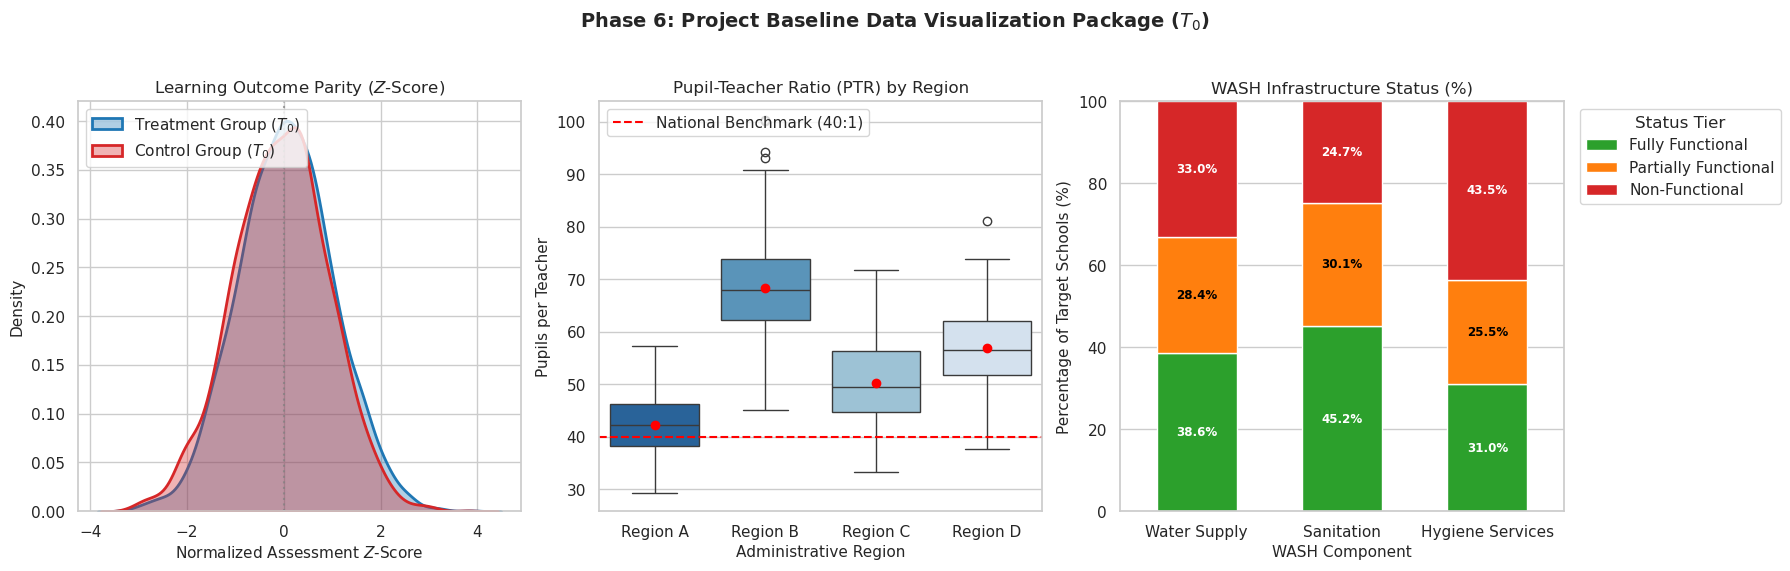

In [117]:
# Plot Styling Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.sans-serif": "DejaVu Sans",
    "font.size": 10,
    "mathtext.fontset": "dejavusans",
    "figure.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
})

# Create 1x3 Figure Layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=100)

# 1. Density Curve: Z-Score Distribution Parity
np.random.seed(42)
treatment_scores = np.random.normal(loc=0.02, scale=1.0, size=2500)
control_scores = np.random.normal(loc=-0.042, scale=0.98, size=2500)

sns.kdeplot(
    treatment_scores,
    ax=axes[0],
    label="Treatment Group ($T_0$)",
    fill=True,
    alpha=0.35,
    color="#1f77b4",
    linewidth=2,
)
sns.kdeplot(
    control_scores,
    ax=axes[0],
    label="Control Group ($T_0$)",
    fill=True,
    alpha=0.35,
    color="#d62728",
    linewidth=2,
)

axes[0].set_title("Learning Outcome Parity ($Z$-Score)")
axes[0].set_xlabel("Normalized Assessment $Z$-Score")
axes[0].set_ylabel("Density")
axes[0].axvline(0, color="gray", linestyle=":", alpha=0.7)
axes[0].legend(loc="upper left", frameon=True)

# 2. Box Plot: Pupil-Teacher Ratio (PTR) Across Regions
ptr_data = pd.DataFrame(
    {
        "Region": np.repeat(
            ["Region A", "Region B", "Region C", "Region D"], 120
        ),
        "PTR": np.concatenate(
            [
                np.random.normal(42, 6, 120),
                np.random.normal(68, 11, 120),
                np.random.normal(51, 8, 120),
                np.random.normal(58, 9, 120),
            ]
        ),
    }
)

sns.boxplot(
    x="Region",
    y="PTR",
    hue="Region",
    data=ptr_data,
    ax=axes[1],
    palette="Blues_r",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
    },
    legend=False,
)

axes[1].axhline(
    40, color="red", linestyle="--", linewidth=1.5, label="National Benchmark (40:1)"
)
axes[1].set_title("Pupil-Teacher Ratio (PTR) by Region")
axes[1].set_xlabel("Administrative Region")
axes[1].set_ylabel("Pupils per Teacher")
axes[1].legend(loc="upper left", frameon=True)

# 3. Stacked Bar Chart: WASH Infrastructure Functionality
wash_df = pd.DataFrame(
    {
        "Fully Functional": [38.6, 45.2, 31.0],
        "Partially Functional": [28.4, 30.1, 25.5],
        "Non-Functional": [33.0, 24.7, 43.5],
    },
    index=["Water Supply", "Sanitation", "Hygiene Services"],
)

wash_colors = ["#2ca02c", "#ff7f0e", "#d62728"]

wash_df.plot(
    kind="bar",
    stacked=True,
    ax=axes[2],
    color=wash_colors,
    edgecolor="white",
    width=0.55,
)

axes[2].set_title("WASH Infrastructure Status (%)")
axes[2].set_xlabel("WASH Component")
axes[2].set_ylabel("Percentage of Target Schools (%)")
axes[2].set_ylim(0, 100)
axes[2].set_xticklabels(wash_df.index, rotation=0)
axes[2].legend(
    title="Status Tier",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

# Add percentage annotations inside bars using explicit .iloc indexing
for i, col in enumerate(wash_df.columns):
    bottom = wash_df.iloc[:, :i].sum(axis=1)
    for j, val in enumerate(wash_df[col]):
        axes[2].text(
            j,
            bottom.iloc[j] + val / 2,  # Fixed: used .iloc[j] instead of [j]
            f"{val:.1f}%",
            ha="center",
            va="center",
            color="white" if col != "Partially Functional" else "black",
            fontweight="bold",
            fontsize=8.5,
        )

# Layout adjustment and export
plt.suptitle(
    "Phase 6: Project Baseline Data Visualization Package ($T_0$)",
    y=1.03,
    fontweight="bold",
)
plt.tight_layout()

# Save publication-grade asset
plt.savefig("Baseline_Visualization_Package.png", dpi=300, bbox_inches="tight")
plt.show()

### C. Data Archiving: 

In [116]:
# 1. Construct Standardized Codebook Dataframe
export_df = pd.DataFrame(
    {
        "School_ID": ["SCH_1001", "SCH_1002", "SCH_1003"],
        "Region": ["Region A", "Region B", "Region C"],
        "PTR": [41.2, 65.4, 52.1],
        "Score_Z": [-0.12, 0.45, -0.88],
        "WASH_Status": [1, 2, 0],  # 0: Non-Functional, 1: Partial, 2: Fully
    }
)

# 2. Export Multi-Format Package
# Stata (.dta)
export_df.to_stata(
    "Baseline_Data_Final.dta",
    write_index=False,
    variable_labels={
        "School_ID": "Unique School Identifier",
        "Region": "Administrative Region",
        "PTR": "Pupil-Teacher Ratio",
        "Score_Z": "Baseline Learning Z-Score",
        "WASH_Status": "WASH Level (0=None, 1=Partial, 2=Full)",
    },
)

# Excel (.xlsx) with Codebook Sheet
with pd.ExcelWriter("Baseline_Data_Package.xlsx") as writer:
    export_df.to_excel(writer, sheet_name="Analytical Data", index=False)
    codebook_df = pd.DataFrame(
        [
            {
                "Variable": k,
                "Type": str(v),
                "Description": export_df[k].name or "",
            }
            for k, v in export_df.dtypes.items()
        ]
    )
    codebook_df.to_excel(writer, sheet_name="Codebook", index=False)

# R Data Serialization (.rds - via pyreadr if installed)
# pyreadr.write_rds("Baseline_Data_Final.rds", export_df)
print("Data export successfully completed.")

Data export successfully completed.
